## References
Dataset: https://huggingface.co/datasets/dair-ai/emotion
Model: https://huggingface.co/vinai/bertweet-base
Model paper: https://aclanthology.org/2020.emnlp-demos.2.pdf

## Loading dataset

In [3]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("dair-ai/emotion")

# Visualizzare la struttura
print(dataset)

# 2. Convertire in Pandas per una rapida analisi (utile per il Report)
# Vediamo un esempio e le etichette
train_df = pd.DataFrame(dataset['train'])
print(train_df.head())

# Mappatura delle etichette (Label Mapping)
# Nel dataset emotion: 0=sadness, 1=joy, 2=love, 3=anger, 4=fear, 5=surprise
labels = dataset['train'].features['label'].names
print(f"Classi disponibili: {labels}")

# 3. Controllo bilanciamento classi (FONDAMENTALE per la relazione)
print(train_df['label'].value_counts())
# Nota: 'joy' è molto più frequente di 'surprise', il modello è sbilanciato.

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3
Classi disponibili: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64


## Prepare the dataset

In [4]:
from transformers import AutoTokenizer

# Carichiamo il tokenizer specifico di BERTweet
model_checkpoint = "vinai/bertweet-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, normalization=True)

# Funzione di tokenizzazione
def preprocess_function(examples):
    # Truncation=True: taglia i testi troppo lunghi
    # Max_length=128: come riportato nel paper di BERTweet-base
    return tokenizer(examples["text"], truncation=True, max_length=128)

# Applichiamo la tokenizzazione a tutto il dataset (Train, Validation, Test)
encoded_dataset = dataset.map(preprocess_function, batched=True)

# Rimuoviamo la colonna 'text' originale perché al modello servono solo i numeri (input_ids)
# Ma teniamo 'label'
encoded_dataset = encoded_dataset.remove_columns(["text"])

# Rinominiamo 'label' in 'labels' perché HuggingFace Trainer si aspetta questo nome esatto
encoded_dataset = encoded_dataset.rename_column("label", "labels")

# Impostiamo il formato per PyTorch
encoded_dataset.set_format("torch")

print("Dataset pronto per il training:")
print(encoded_dataset['train'][0]) # Vedrete 'input_ids', 'token_type_ids', 'attention_mask', 'labels'

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Dataset pronto per il training:
{'labels': tensor(0), 'input_ids': tensor([    0,    37,  1403,   174, 45115,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1])}


## Loading the model

In [5]:
import numpy as np
import evaluate
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Mappatura delle etichette (Utile per leggere i risultati)
# Dal dataset dair-ai/emotion:
id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label2id = {"sadness": 0, "joy": 1, "love": 2, "anger": 3, "fear": 4, "surprise": 5}

# 2. Caricamento del Modello Pre-addestrato
# carichiamo BERTweet e specifichiamo che vogliamo 6 output (num_labels=6)
model_checkpoint = "vinai/bertweet-base"
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

# freeze all base model parameters
for name, param in model.base_model.named_parameters():
    param.requires_grad = False


for name, param in model.base_model.named_parameters():
    if "pooler" in name:
        param.requires_grad = True

# -------------------------------------

# Verifica: Stampiamo quanti parametri verranno effettivamente addestrati
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())

print(f"Parametri totali: {all_params:,}")
print(f"Parametri addestrabili (Testa): {trainable_params:,}")
print(f"Percentuale addestrabile: {100 * trainable_params / all_params:.2f}%")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Parametri totali: 134,904,582
Parametri addestrabili (Testa): 595,206
Percentuale addestrabile: 0.44%


## Define evaluation metrics

In [6]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    acc = accuracy.compute(predictions=predictions, references=labels)
    f1_score = f1.compute(predictions=predictions, references=labels, average="macro")
    
    return {"accuracy": acc["accuracy"], "f1": f1_score["f1"]}

## Eval base model

In [7]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Configuriamo argomenti base solo per la valutazione
training_args = TrainingArguments(
    #output_dir="./bertweet-emotion-checkpoints",
    per_device_eval_batch_size=32, # Batch size per valutazione
    report_to="none" # Disabilita wandb/tensorboard per ora
)

# Inizializziamo il Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("--- AVVIO VALUTAZIONE BASELINE (PRE-TRAINING) ---")
baseline_metrics = trainer.evaluate(encoded_dataset["test"])

print("\nRisultati Baseline (Modello non addestrato):")
print(f"Accuracy: {baseline_metrics['eval_accuracy']:.4f}")
print(f"F1-Score: {baseline_metrics['eval_f1']:.4f}")
print("-------------------------------------------------")

--- AVVIO VALUTAZIONE BASELINE (PRE-TRAINING) ---



Risultati Baseline (Modello non addestrato):
Accuracy: 0.3285
F1-Score: 0.1011
-------------------------------------------------


## Hyperparameter tuning (Ablation)

In [20]:
import itertools

learning_rates = [1e-3, 1e-04, 1e-05]
batch_sizes = [8, 16]

best_accuracy = 0
best_params = {}
tl_results = []

print(f"--- INIZIO HYPERPARAMETER TUNING (Grid Search) ---")
print(f"Totale combinazioni da testare: {len(learning_rates) * len(batch_sizes)}")

# Iteriamo su tutte le combinazioni
for lr, bs in itertools.product(learning_rates, batch_sizes):
    
    print(f"\nTesting: LR={lr}, Batch={bs}")
    
    # A. RICARICARE IL MODELLO (Fondamentale: ripartiamo da zero ogni volta)
    model = AutoModelForSequenceClassification.from_pretrained(
        "vinai/bertweet-base",
        num_labels=6,
        id2label=id2label,
        label2id=label2id
    )
    
    # B. APPLICARE IL FREEZING (Transfer Learning puro)
    for param in model.base_model.parameters():
        param.requires_grad = False
    
    # C. DEFINIRE GLI ARGOMENTI CON I PARAMETRI CORRENTI
    training_args = TrainingArguments(
        output_dir=f"./tuning_lr{lr}_bs{bs}",
        eval_strategy="epoch",
        save_strategy="no",        # Non salviamo i checkpoint intermedi per risparmiare spazio
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=4,        # Riduciamo a 4 per il tuning (basta per vedere il trend)
        weight_decay=0.01,
        report_to="none",
        load_best_model_at_end=False # Non serve qui, valutiamo alla fine
    )
    
    # D. INIZIALIZZARE IL TRAINER
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )
    
    # E. TRAINING E VALUTAZIONE
    trainer.train()
    eval_result = trainer.evaluate(encoded_dataset["test"])
    acc_score = eval_result['eval_accuracy']
    f1_score = eval_result['eval_f1']
    
    # Salviamo i risultati
    tl_results.append({'lr': lr, 'batch': bs, 'accuracy': acc_score, 'f1': f1_score})
    print(f"--> Risultato: Accuracy = {acc_score:.4f}, F1 = {f1_score:.4f}")
    
    # Aggiorniamo il best model
    if acc_score > best_accuracy:
        best_accuracy = acc_score
        best_params = {'lr': lr, 'batch': bs}

print("\n---------------------------------------------")
print(f"MIGLIOR RISULTATO TROVATO: Accuracy {best_accuracy:.4f}")
print(f"MIGLIORI PARAMETRI: {best_params}")
print("---------------------------------------------")

# Stampa tabella riassuntiva per il Report
import pandas as pd
df_results = pd.DataFrame(tl_results)
print(df_results.sort_values(by="accuracy", ascending=False))

--- INIZIO HYPERPARAMETER TUNING (Grid Search) ---
Totale combinazioni da testare: 6

Testing: LR=0.001, Batch=8


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.459470,1.386373,0.461000,0.222904
2,1.413865,1.329908,0.511500,0.293717
3,1.379501,1.291258,0.529000,0.318428
4,1.287637,1.247480,0.542000,0.319404


--> Risultato: Accuracy = 0.5395, F1 = 0.2976

Testing: LR=0.001, Batch=16


...

--> Risultato: Accuracy = 0.4490, F1 = 0.1757

Testing: LR=1e-05, Batch=16


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.571923,1.567440,0.352500,0.087546
2,1.559176,1.557080,0.384000,0.127094
3,1.553066,1.551394,0.384000,0.126523
4,1.540808,1.549660,0.402000,0.142669


--> Risultato: Accuracy = 0.4085, F1 = 0.1491

---------------------------------------------
MIGLIOR RISULTATO TROVATO: Accuracy 0.5445
MIGLIORI PARAMETRI: {'lr': 0.001, 'batch': 16}
---------------------------------------------
        lr  batch  accuracy        f1
1  0.00100     16    0.5445  0.299783
0  0.00100      8    0.5395  0.297569
2  0.00010      8    0.5120  0.225057
3  0.00010     16    0.5025  0.208037
4  0.00001      8    0.4490  0.175697
5  0.00001     16    0.4085  0.149144


## Fine tuning (Transfer learning)

In [21]:
lr = 1e-3
batch_size = 8
num_epochs = 10

training_args = TrainingArguments(
    #output_dir="./bertweet-emotion-finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=lr,
    per_device_train_batch_size=batch_size,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="tensorboard"
)

# Aggiorniamo il trainer con i nuovi argomenti
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    processing_class=tokenizer
)

print("\n--- AVVIO FINE-TUNING (TRANSFER LEARNING) ---")
trainer.train()


--- AVVIO FINE-TUNING (TRANSFER LEARNING) ---


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.466851,1.379923,0.458500,0.216554
2,1.440037,1.317934,0.507500,0.251100
3,1.420614,1.401757,0.429000,0.216013
4,1.347317,1.281561,0.541000,0.312211
5,1.370905,1.279125,0.522000,0.304629
6,1.345003,1.267139,0.515000,0.267428
7,1.339984,1.231544,0.541500,0.286729
8,1.306165,1.194094,0.552500,0.331565
9,1.322680,1.199519,0.567000,0.360079
10,1.299233,1.193368,0.563500,0.350881


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=20000, training_loss=1.3744424713134766, metrics={'train_runtime': 405.4384, 'train_samples_per_second': 394.635, 'train_steps_per_second': 49.329, 'total_flos': 3323331202506912.0, 'train_loss': 1.3744424713134766, 'epoch': 10.0})

## Eval trained model

In [22]:
print("--- VALUTAZIONE POST-TRAINING ---")
final_metrics = trainer.evaluate(encoded_dataset["test"])

print("\nConfronto Finale:")
print(f"PRIMA  -> Accuracy: {baseline_metrics['eval_accuracy']:.4f}, F1: {baseline_metrics['eval_f1']:.4f}")
print(f"DOPO   -> Accuracy: {final_metrics['eval_accuracy']:.4f}, F1: {final_metrics['eval_f1']:.4f}")

--- VALUTAZIONE POST-TRAINING ---



Confronto Finale:
PRIMA  -> Accuracy: 0.0935, F1: 0.0523
DOPO   -> Accuracy: 0.5670, F1: 0.3601


## LoRA config tuning (Ablation)

In [23]:
from peft import get_peft_model, LoraConfig, TaskType
import itertools

rangos = [8, 16, 32]
target_modules = [["query", "value", "key", "dense"], ["query", "value"]]
learning_rates = [1e-3, 1e-4, 1e-5]
batch_sizes = [8, 16]

best_accuracy = 0
best_configs = {}
lora_results = []

print(f"--- INIZIO LORA CONFIG TUNING (Grid Search) ---")
print(f"Totale combinazioni da testare: {len(rangos) * len(target_modules) * len(learning_rates) * len(batch_sizes)}")

for r, tm, lr, bs in itertools.product(rangos, target_modules, learning_rates, batch_sizes):
    print(f"\nTesting: Rango={r}, Target Modules={tm}, Learning Rate={lr}, Batch Size={bs}")
    
    # Ricarichiamo il modello base
    model = AutoModelForSequenceClassification.from_pretrained(
        "vinai/bertweet-base",
        num_labels=6,
        id2label=id2label,
        label2id=label2id
    )
    
    # Configuriamo LoRA
    peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False, 
        r=r,
        lora_alpha=r*2,
        target_modules=tm,
        lora_dropout=0.1,
        modules_to_save=["classifier"]
    )
    
    # Applichiamo LoRA al modello
    model = get_peft_model(model, peft_config)
    
    # Configuriamo il Trainer con i parametri migliori trovati prima
    training_args = TrainingArguments(
        output_dir=f"./lora_r{r}_tm{'_'.join(tm)}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=4,
        weight_decay=0.01,
        report_to="none",
        load_best_model_at_end=False
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )
    
    trainer.train()
    eval_result = trainer.evaluate(encoded_dataset["test"])
    acc_score = eval_result['eval_accuracy']
    f1_score = eval_result['eval_f1']
    
    lora_results.append({'r': r, 'target_modules': tm, 'learning_rate': lr, 'batch_size': bs, 'accuracy': acc_score, 'f1': f1_score})
    print(f"--> Risultato: Accuracy = {acc_score:.4f}, F1 = {f1_score:.4f}")
    
    if acc_score > best_accuracy:
        best_accuracy = acc_score
        best_configs = {'r': r, 'target_modules': tm, 'learning_rate': lr, 'batch_size': bs}

print(pd.DataFrame(lora_results))

--- INIZIO LORA CONFIG TUNING (Grid Search) ---
Totale combinazioni da testare: 36

Testing: Rango=8, Target Modules=['query', 'value', 'key', 'dense'], Learning Rate=0.001, Batch Size=8


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.452104,0.620788,0.821500,0.786537
2,0.296349,0.298214,0.915500,0.884449
3,0.187215,0.188087,0.934000,0.908031
4,0.129457,0.146564,0.943000,0.918361


--> Risultato: Accuracy = 0.9325, F1 = 0.8845

Testing: Rango=8, Target Modules=['query', 'value', 'key', 'dense'], Learning Rate=0.001, Batch Size=16


...

--> Risultato: Accuracy = 0.7745, F1 = 0.5621

Testing: Rango=32, Target Modules=['query', 'value'], Learning Rate=1e-05, Batch Size=16


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.532204,1.364561,0.545500,0.222718
2,1.118340,1.035357,0.596000,0.266647
3,0.981973,0.911021,0.673500,0.420278
4,0.910579,0.869850,0.695500,0.452848


--> Risultato: Accuracy = 0.7100, F1 = 0.4600
     r              target_modules  learning_rate  batch_size  accuracy  \
0    8  [query, value, key, dense]        0.00100           8    0.9325   
1    8  [query, value, key, dense]        0.00100          16    0.9335   
2    8  [query, value, key, dense]        0.00010           8    0.9260   
3    8  [query, value, key, dense]        0.00010          16    0.9250   
4    8  [query, value, key, dense]        0.00001           8    0.8060   
5    8  [query, value, key, dense]        0.00001          16    0.7545   
6    8              [query, value]        0.00100           8    0.9235   
7    8              [query, value]        0.00100          16    0.9280   
8    8              [query, value]        0.00010           8    0.9115   
9    8              [query, value]        0.00010          16    0.9060   
10   8              [query, value]        0.00001           8    0.6730   
11   8              [query, value]        0.00001     

## Fine tuning (LoRA)

In [11]:
from peft import get_peft_model, LoraConfig, TaskType

model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Task: Sequence Classification
    inference_mode=False, 
    r=8,                       # Rango: dimensione delle matrici LoRA (16 è un ottimo bilanciamento)
    lora_alpha=16,              # Scaling factor (solitamente 2x r)
    lora_dropout=0.1,           # Un po' di dropout per evitare overfitting
    target_modules=["query", "value", "key", "dense"], # Dove applicare LoRA (nei layer di self-attention)
    modules_to_save=["classifier"]
)

model = get_peft_model(model, peft_config)

# Stampiamo i parametri addestrabili per il Report
model.print_trainable_parameters()

training_args = TrainingArguments(
    output_dir="./bertweet-emotion-lora",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",

    lr_scheduler_type="cosine",      # Questo fa la differenza nelle ultime epoche
    warmup_ratio=0.1,                # 10% di riscaldamento
)

# 5. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"], 
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

print("\n--- AVVIO FINE-TUNING CON LoRA (Low-Rank Adaptation) ---")
trainer.train()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

trainable params: 1,922,310 || all params: 136,826,892 || trainable%: 1.4049

--- AVVIO FINE-TUNING CON LoRA (Low-Rank Adaptation) ---


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.461385,0.300725,0.908500,0.883049
2,0.218391,0.186654,0.932500,0.906462
3,0.168255,0.162400,0.941500,0.920119
4,0.145261,0.147786,0.941000,0.920399
5,0.112862,0.145223,0.939500,0.917319
6,0.097940,0.140439,0.942000,0.916858
7,0.085160,0.148407,0.937500,0.912494
8,0.076575,0.154621,0.936000,0.910012
9,0.064604,0.157818,0.939000,0.914360
10,0.065708,0.158191,0.941000,0.917572


TrainOutput(global_step=10000, training_loss=0.19490506649017333, metrics={'train_runtime': 803.7359, 'train_samples_per_second': 199.07, 'train_steps_per_second': 12.442, 'total_flos': 3872383178714496.0, 'train_loss': 0.19490506649017333, 'epoch': 10.0})

## In-context learning (zero-shot)

In [25]:
import torch
from transformers import AutoModelForMaskedLM

model_checkpoint = "vinai/bertweet-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

verbalizers_map = {
    0: ["sadness", "sad", "depressed", "grief", "crying", "miserable"],  # sadness
    1: ["joy", "happy", "glad", "excited", "delighted"],      # joy
    2: ["love", "loved", "loving", "sweet", "caring"],        # love
    3: ["anger", "angry", "mad", "furious", "hate", "annoyed"],        # anger
    4: ["fear", "scared", "afraid", "terrified", "nervous"],  # fear
    5: ["surprise", "shocked", "surprised", "amazed", "stunned", "wow"]   # surprise
}

# Otteniamo gli ID dei token per queste parole
verbalizer_ids = {}
for label, words in verbalizers_map.items():
    ids = []
    for w in words:
        token = tokenizer.encode(" " + w, add_special_tokens=False)[0]
        ids.append(token)
    verbalizer_ids[label] = ids

# Carichiamo il dataset
dataset = load_dataset("dair-ai/emotion")
test_dataset = dataset['test'] # 2000 esempi
train_dataset = dataset['train']

# Selezioniamo 1 esempio breve per ogni classe dal train set da usare come contesto
shot_bank = []
for label_id in range(6):
    # Cerchiamo un esempio corto (< 15 parole) per risparmiare token
    candidates = [ex for ex in train_dataset if ex['label'] == label_id and len(ex['text'].split()) < 15]
    if candidates:
        shot_bank.append(candidates[0]) # Ne prendiamo uno a caso (il primo)

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie roberta.embeddings.word_embeddings.weight to lm_head.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie lm_head.bias to lm_head.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
RobertaForMaskedLM LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
def predict_emotion_k_shot(text, k=0):
    prompt = ""

    if k > 0:
        selected_shots = shot_bank[:k]
        for shot in selected_shots:
            label_word = verbalizers_map[shot['label']][0]  # Prendiamo la prima parola del verbalizer
            prompt += f"{shot['text']} It makes me feel {label_word}. "

    prompt += f"{text} It makes me feel <mask>."
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=128).to(device)
    
    # Troviamo la posizione del token <mask>
    # In BERTweet/RoBERTa il mask token id è solitamente tokenizer.mask_token_id
    mask_index = (inputs.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
    
    if len(mask_index) == 0:
        return -1  # <mask> troncato

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        
    # Prendiamo i logit solo alla posizione della maschera
    mask_logits = logits[0, mask_index, :]
    
    # Ora guardiamo SOLO i punteggi delle nostre parole target (sad, happy, ecc.)
    # Non ci interessa se il modello predice "hungry", ci interessa quale delle 6 emozioni vince.
    best_score = -float('inf')
    predicted_label = -1
    
    for label, tokens in verbalizer_ids.items():
        class_logits = mask_logits[0, tokens]

        score = torch.sum(torch.exp(class_logits)).item()
        
        if score > best_score:
            best_score = score
            predicted_label = label
            
    return predicted_label

In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

print("Avvio valutazione k-shot (In-Context Learning)...")
    
predictions = []
true_labels = []
icl_results = []

k_values = [0, 1, 2, 3, 4, 5] # Proviamo da 0 a 5 shot

for k in k_values:
    print(f"\nTesting k={k} shot...")
    preds = []
    trues = []
    truncated_count = 0

    for i in tqdm(range(len(test_dataset))): 
        text = test_dataset[i]['text']
        label = test_dataset[i]['label']
        
        pred = predict_emotion_k_shot(text, k)

        if pred == -1:
            truncated_count += 1
            continue
        
        predictions.append(pred)
        true_labels.append(label)

    # Calcolo metriche
    acc = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')

    icl_results.append({'k': k, 'truncated': truncated_count, 'acc': acc, 'f1': f1})
    print(f"--> k={k}: Accuracy={acc:.4f}, F1={f1:.4f} (Troncati: {truncated_count})")

print(pd.DataFrame(icl_results))

Avvio valutazione k-shot (In-Context Learning)...

Testing k=0 shot...


100%|██████████| 2000/2000 [00:28<00:00, 71.08it/s]


--> k=0: Accuracy=0.4930, F1=0.2463 (Troncati: 0)

Testing k=1 shot...


100%|██████████| 2000/2000 [00:28<00:00, 70.80it/s]


--> k=1: Accuracy=0.4688, F1=0.2228 (Troncati: 0)

Testing k=2 shot...


...

--> k=3: Accuracy=0.4840, F1=0.2459 (Troncati: 0)

Testing k=4 shot...


100%|██████████| 2000/2000 [00:31<00:00, 63.91it/s]


--> k=4: Accuracy=0.4860, F1=0.2519 (Troncati: 0)

Testing k=5 shot...


100%|██████████| 2000/2000 [00:32<00:00, 61.86it/s]

--> k=5: Accuracy=0.4889, F1=0.2577 (Troncati: 25)
   k       acc        f1  truncated
0  0  0.493000  0.246325          0
1  1  0.468750  0.222799          0
2  2  0.475000  0.235495          0
3  3  0.484000  0.245921          0
4  4  0.486000  0.251874          0
5  5  0.488852  0.257740         25


## Final results

In [28]:
# Uniamo tutti i risultati in un unico DataFrame
all_results = tl_results + lora_results + icl_results
df_final = pd.DataFrame(all_results)

# Formattazione per il report
print("\n=== RISULTATI FINALI STUDIO ABLATION ===")
print(df_final.sort_values(by="accuracy", ascending=True))

# Codice opzionale per salvare in CSV
# df_final.to_csv("ablation_study_results.csv", index=False)


=== RISULTATI FINALI STUDIO ABLATION ===
         lr  batch  accuracy        f1     r              target_modules  \
30      NaN    NaN    0.3475  0.085962  32.0  [query, value, key, dense]   
31      NaN    NaN    0.3475  0.085962  32.0  [query, value, key, dense]   
18      NaN    NaN    0.3475  0.085962  16.0  [query, value, key, dense]   
37      NaN    NaN    0.3475  0.085962  32.0              [query, value]   
36      NaN    NaN    0.3475  0.085962  32.0              [query, value]   
5   0.00001   16.0    0.4085  0.149144   NaN                         NaN   
4   0.00001    8.0    0.4490  0.175697   NaN                         NaN   
3   0.00010   16.0    0.5025  0.208037   NaN                         NaN   
2   0.00010    8.0    0.5120  0.225057   NaN                         NaN   
0   0.00100    8.0    0.5395  0.297569   NaN                         NaN   
1   0.00100   16.0    0.5445  0.299783   NaN                         NaN   
17      NaN    NaN    0.5660  0.232196   8.0  

## Grafico di confronto

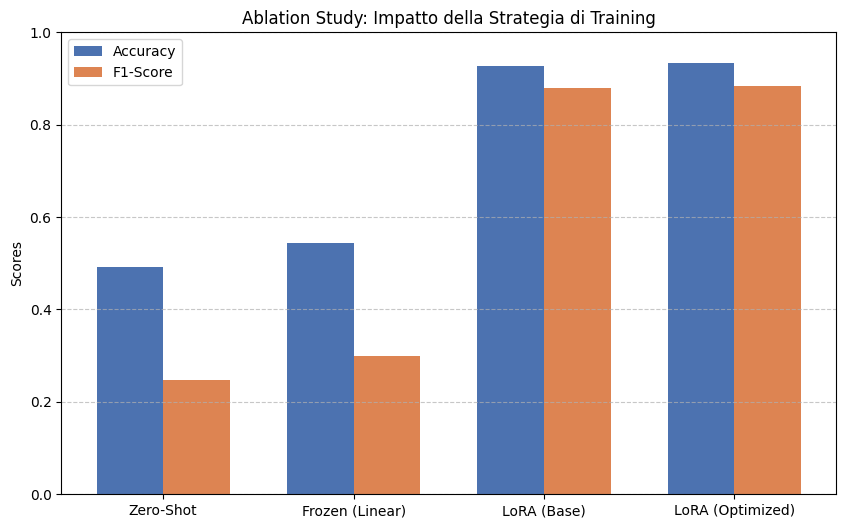

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Inserisci qui i TUOI numeri esatti
strategies = ['Zero-Shot', 'Frozen (Linear)', 'LoRA (Base)', 'LoRA (Optimized)']
accuracies = [0.4930, 0.5445, 0.9280, 0.9335] 
f1_scores =  [0.2463, 0.2998, 0.8796, 0.8828]

x = np.arange(len(strategies))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#4c72b0')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#dd8452')

ax.set_ylabel('Scores')
ax.set_title('Ablation Study: Impatto della Strategia di Training')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Analisi degli errori (Confusion Matrix)

Generazione previsioni sul Validation Set...


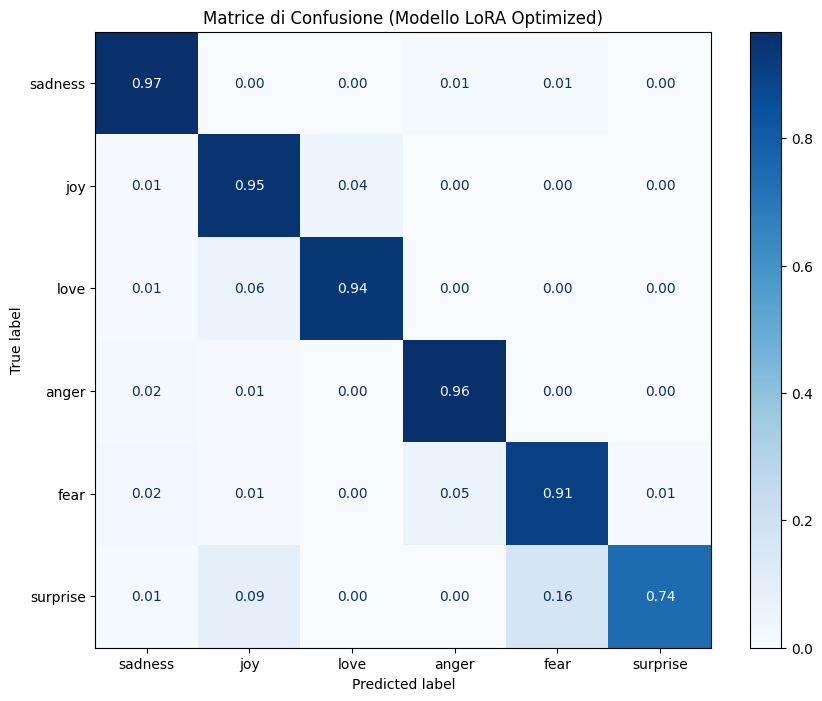

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Carica il tuo modello MIGLIORE (quello LoRA Optimized)
# (Assumiamo che 'trainer' contenga ancora l'ultimo modello addestrato)
# Se hai chiuso la sessione, ricaricalo con:
# model = AutoModelForSequenceClassification.from_pretrained("./bertweet-emotion-ultimate")
# trainer = Trainer(model=model, ...)

print("Generazione previsioni sul Validation Set...")
predictions = trainer.predict(encoded_dataset["validation"])
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# 2. Calcola la matrice
cm = confusion_matrix(labels, preds, normalize='true') # Normalize='true' mostra le percentuali

# 3. Disegna
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label2id.keys()))
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Matrice di Confusione (Modello LoRA Optimized)")
plt.show()